In [1]:
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("ggplot")

In [2]:
df = pd.read_csv("../data/Dataset .csv")

df.head()

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229


In [3]:
df = df.dropna(subset=["Cuisines"])

print("Dataset Shape:", df.shape)

Dataset Shape: (9542, 21)


In [4]:
combination_count = (
    df["Cuisines"]
    .value_counts()
    .reset_index()
)

combination_count.columns = [
    "Cuisine Combination",
    "Restaurant Count"
]

combination_count.head(10)

,Cuisine Combination,Restaurant Count
0,North Indian,936
1,"North Indian, Chinese",511
2,Chinese,354
3,Fast Food,354
4,"North Indian, Mughlai",334
5,Cafe,299
6,Bakery,218
7,"North Indian, Mughlai, Chinese",197
8,"Bakery, Desserts",170
9,Street Food,149


In [5]:
top10 = combination_count.head(10)

top10

,Cuisine Combination,Restaurant Count
0,North Indian,936
1,"North Indian, Chinese",511
2,Chinese,354
3,Fast Food,354
4,"North Indian, Mughlai",334
5,Cafe,299
6,Bakery,218
7,"North Indian, Mughlai, Chinese",197
8,"Bakery, Desserts",170
9,Street Food,149


In [6]:
avg_rating = (
    df.groupby("Cuisines")["Aggregate rating"]
      .mean()
      .reset_index()
)

avg_rating.columns = [
    "Cuisine Combination",
    "Average Rating"
]

avg_rating = avg_rating.sort_values(
    by="Average Rating",
    ascending=False
)

avg_rating.head(10)

,Cuisine Combination,Average Rating
302,"Burger, Bar Food, Steak",4.9
33,"American, Burger, Grill",4.9
37,"American, Caribbean, Seafood",4.9
41,"American, Coffee and Tea",4.9
1214,"Mexican, American, Healthy Food",4.9
1034,"Italian, Bakery, Continental",4.9
169,"BBQ, Breakfast, Southern",4.9
808,"European, German",4.9
949,"Hawaiian, Seafood",4.9
1779,"Sunda, Indonesian",4.9


In [7]:
summary = combination_count.merge(
    avg_rating,
    on="Cuisine Combination"
)

summary.head(10)

,Cuisine Combination,Restaurant Count,Average Rating
0,North Indian,936,1.672329
1,"North Indian, Chinese",511,2.421722
2,Chinese,354,2.042090
3,Fast Food,354,2.118362
4,"North Indian, Mughlai",334,2.888623
5,Cafe,299,2.890970
6,Bakery,218,1.924312
7,"North Indian, Mughlai, Chinese",197,2.568528
8,"Bakery, Desserts",170,2.317647
9,Street Food,149,2.161745


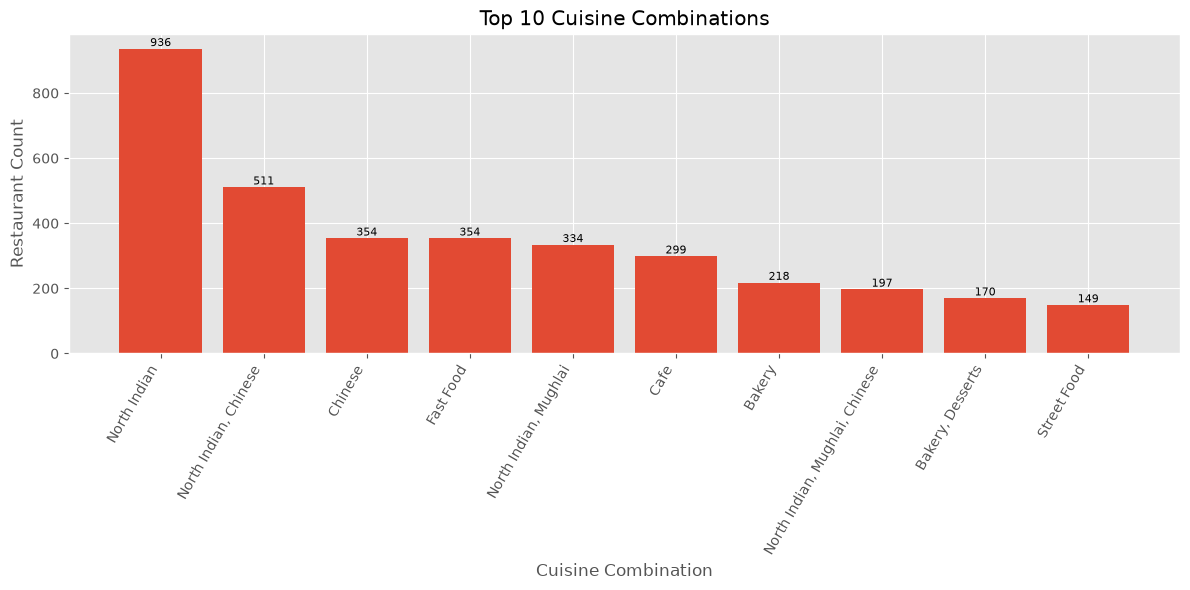

In [8]:
plt.figure(figsize=(12,6))

bars = plt.bar(
    top10["Cuisine Combination"],
    top10["Restaurant Count"]
)

plt.xticks(rotation=60, ha="right")

plt.title("Top 10 Cuisine Combinations")
plt.xlabel("Cuisine Combination")
plt.ylabel("Restaurant Count")

for bar in bars:
    plt.text(
        bar.get_x()+bar.get_width()/2,
        bar.get_height(),
        int(bar.get_height()),
        ha="center",
        va="bottom",
        fontsize=8
    )

plt.tight_layout()
plt.show()

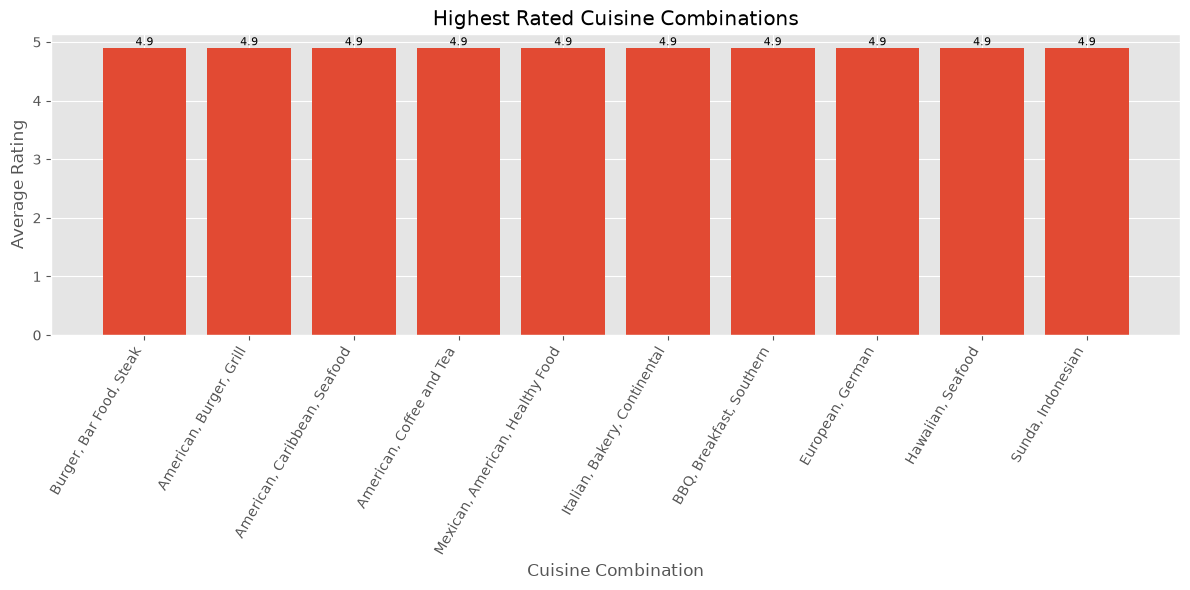

In [9]:
best10 = avg_rating.head(10)

plt.figure(figsize=(12,6))

bars = plt.bar(
    best10["Cuisine Combination"],
    best10["Average Rating"]
)

plt.xticks(rotation=60, ha="right")

plt.title("Highest Rated Cuisine Combinations")
plt.xlabel("Cuisine Combination")
plt.ylabel("Average Rating")

for bar in bars:
    plt.text(
        bar.get_x()+bar.get_width()/2,
        bar.get_height(),
        round(bar.get_height(),2),
        ha="center",
        va="bottom",
        fontsize=8
    )

plt.tight_layout()
plt.show()

In [10]:
top20 = summary.head(20)

correlation = top20["Restaurant Count"].corr(
    top20["Average Rating"]
)

print(f"Correlation: {correlation:.3f}")

Correlation: -0.169


In [11]:
summary.head(20)

,Cuisine Combination,Restaurant Count,Average Rating
0,North Indian,936,1.672329
1,"North Indian, Chinese",511,2.421722
2,Chinese,354,2.042090
3,Fast Food,354,2.118362
4,"North Indian, Mughlai",334,2.888623
5,Cafe,299,2.890970
6,Bakery,218,1.924312
7,"North Indian, Mughlai, Chinese",197,2.568528
8,"Bakery, Desserts",170,2.317647
9,Street Food,149,2.161745


# Observations

- Identified the most common cuisine combinations in the dataset.
- Calculated the average rating for each cuisine combination.
- Compared the popularity and quality of different cuisine combinations.
- Visualized the top 10 most common cuisine combinations.
- Visualized the highest-rated cuisine combinations.
- Measured the relationship between popularity and average ratings using correlation analysis.